In [ ]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-430bf94f-1744-0686-d7da-41e02ee06864)


In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2025-06-26 08:05:03--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-06-26 08:05:03 (95.1 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]



In [ ]:
from helper_functions import plot_loss_curves, unzip_data, create_tensorboard_callback, compare_historys

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
unzip_data('nlp_getting_started.zip')

--2025-06-26 08:05:13--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.134.207, 74.125.139.207, 173.194.210.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.134.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip.1’

nlp_getting_started 100%[===================>] 593.11K  --.-KB/s    in 0.004s  

2025-06-26 08:05:13 (156 MB/s) - ‘nlp_getting_started.zip.1’ saved [607343/607343]



In [ ]:
# reading files using pandas
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv('test.csv')

train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [ ]:
#shuffling

train_df_shuffled = train_df.sample(frac = 1, random_state= 42)
train_df_shuffled

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0
...,...,...,...,...,...
5226,7470,obliteration,Merica!,@Eganator2000 There aren't many Obliteration s...,0
5390,7691,panic,NaN,just had a panic attack bc I don't have enough...,0
860,1242,blood,NaN,Omron HEM-712C Automatic Blood Pressure Monito...,0
7603,10862,NaN,NaN,Officials say a quarantine is in place at an A...,1


# **Unbalanced Classification**

In [ ]:
# total examples of each class
train_df.target.value_counts()

,count
target,
0,4342
1,3271


In [ ]:
len(train_df), len(test_df)

(7613, 3263)

In [ ]:
# Visualising Random Samples

import random
random_index = random.randint(0, len(train_df)-5)

for row in train_df_shuffled[['text','target']][random_index:random_index+5].itertuples():
  _,text,target = row
  print(f"Target: {target}", "(real disaster)" if target > 0 else "(not a real disaster )")
  print(f"Text:\n {text}\n")
  print('---\n')

Target: 0 (not a real disaster )
Text:
 For sixth year in a row premium costs for windstorm insurance to climb. This time by 5 percent. #GalvNews  https://t.co/Cm9TvE2Vsq

---

Target: 0 (not a real disaster )
Text:
 'When you attack women's health you attack America's health.' Hillary Clinton shows how to #StandwithPP http://t.co/HXdG254dHO

---

Target: 0 (not a real disaster )
Text:
 Fatality  https://t.co/407V1y4HHg

---

Target: 0 (not a real disaster )
Text:
 I JUST SCREAMED SIDJSJDJEKDJSKDJD . I CANT STAND YOU ?? https://t.co/0Vcsafx9bY

---

Target: 0 (not a real disaster )
Text:
 Court back in session. Testimony continues with med. examiner discussing gunshot wounds #KerrickTrial

---



In [ ]:
from sklearn.model_selection import train_test_split

train_sentences, val_sentences, train_labels, val_labels = train_test_split(train_df_shuffled['text'].to_numpy(),
                                                                            train_df_shuffled['target'].to_numpy(),
                                                                            test_size= 0.1,
                                                                            random_state= 42)

In [ ]:
len(train_sentences), len(val_sentences), len(train_labels), len(val_labels)

(6851, 762, 6851, 762)

In [ ]:
train_sentences[:10], train_labels[:10]

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

# **Converting Text to Number**

# Text_Vectorisation == Tokenization

In [ ]:
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=None, # how many words in the vocabulary (all of the different words in your text)
                                    standardize="lower_and_strip_punctuation", # how to process text
                                    split="whitespace", # how to split tokens
                                    ngrams=None, # create groups of n-words?
                                    output_mode="int", # how to map tokens to numbers
                                    output_sequence_length=None) # how long should the output sequence of tokens be?
                                    # pad_to_max_tokens=True) # Not valid if using max_tokens=None

In [ ]:
train_sentences[0].split()

['@mogacola', '@zamtriossu', 'i', 'screamed', 'after', 'hitting', 'tweet']

In [ ]:
#finding avgerage number of tokens in training tweets
round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))

15

In [ ]:
# Setup text vectorization with custom variables
max_vocab_length = 10000 # max number of words to have in our vocabulary
max_length = 15 # max length our sequences will be (e.g. how many words from a Tweet does our model see?)

text_vectorizer = TextVectorization(max_tokens=max_vocab_length,
                                    output_mode="int",
                                    output_sequence_length=max_length)

In [ ]:
text_vectorizer.adapt(train_sentences)

In [ ]:
sample_sentence = "Hurricane wind speed is more than thunderstorm"
x = text_vectorizer([sample_sentence])
print(x)

tf.Tensor(
[[ 346  326 3392    9   51   76  283    0    0    0    0    0    0    0
     0]], shape=(1, 15), dtype=int64)


In [ ]:
random_sentence = random.choice(train_sentences)
print(f"Original sentence:\n{random_sentence}\
       \n\nVectorized version:\n")
text_vectorizer([random_sentence])

Original sentence:
Kai Forbath just demolished a weather station set up on a drill field with a missed field goal. Thing just exploded into metal bits.       

Vectorized version:



<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[   1,    1,   29,  606,    3,  229, 2678,  284,   27,   11,    3,
        2135, 2458,   14,    3]])>

In [ ]:
# Get the unique words in the vocabulary
words_in_vocab = text_vectorizer.get_vocabulary()
top_5_words = words_in_vocab[:5] # most common tokens (notice the [UNK] token for "unknown" words)
bottom_5_words = words_in_vocab[-5:] # least common tokens
print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"Top 5 most common words: {top_5_words}")
print(f"Bottom 5 least common words: {bottom_5_words}")

Number of words in vocab: 10000
Top 5 most common words: ['', '[UNK]', 'the', 'a', 'in']
Bottom 5 least common words: ['pages', 'paeds', 'pads', 'padres', 'paddytomlinson1']


# Creating Embedding using Tensorflow Embedding layer

Embedding layer coverts -- positive integers into feature vector

In [ ]:
import tensorflow as tf

tf.random.set_seed(42)
from tensorflow.keras import layers

embedding = layers.Embedding(input_dim=max_vocab_length, # set input shape
                             output_dim=128, # set size of embedding vector
                             embeddings_initializer="uniform", # default, intialize randomly
                             input_length=max_length, # how long is each input
                             name="embedding_1")

embedding


In [ ]:
# Get a random sentence from training set
random_sentence = random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\
      \n\nEmbedded version:")

# Embed the random sentence (turn it into numerical representation)
sample_embed = embedding(text_vectorizer([random_sentence]))
sample_embed

Original text:
@WoundedPigeon http://t.co/s9soAeVcVo Detonate by @ApolloBrown ft. M.O.P.      

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[-0.00617487,  0.00512394, -0.02292156, ...,  0.02754814,
         -0.01917253, -0.03342699],
        [ 0.01198335, -0.02144259, -0.02383657, ...,  0.01588253,
          0.04097774, -0.04138372],
        [ 0.00086892, -0.00921605,  0.04916375, ...,  0.02009397,
          0.02180422,  0.0095793 ],
        ...,
        [-0.03260529, -0.00518854,  0.02630481, ..., -0.04359036,
          0.03022721,  0.02581533],
        [-0.03260529, -0.00518854,  0.02630481, ..., -0.04359036,
          0.03022721,  0.02581533],
        [-0.03260529, -0.00518854,  0.02630481, ..., -0.04359036,
          0.03022721,  0.02581533]]], dtype=float32)>

In [ ]:
sample_embed[0][0]

<tf.Tensor: shape=(128,), dtype=float32, numpy=
array([-0.00617487,  0.00512394, -0.02292156,  0.02746541, -0.04336934,
       -0.0408187 , -0.04991555,  0.03493501, -0.04184421,  0.02116681,
        0.02856863,  0.02525231, -0.00363841,  0.00650739, -0.00882609,
        0.00838947, -0.01583945, -0.02752709,  0.04060054, -0.0173359 ,
       -0.03910915, -0.01774812, -0.02443906, -0.00453719, -0.00993229,
        0.00553054,  0.00024928,  0.03154801, -0.00489358, -0.03208302,
        0.03201935,  0.03781154,  0.02251636, -0.01195021,  0.02846417,
       -0.04499048,  0.04109905,  0.04037053,  0.03126984, -0.04753163,
        0.00800903,  0.00157638, -0.00694287, -0.02288855,  0.01699125,
       -0.0449993 ,  0.01401779,  0.00930952, -0.02491626,  0.02081035,
       -0.02759234,  0.0014503 , -0.00107417, -0.03202007,  0.02200455,
       -0.00618497,  0.00168681, -0.01864583,  0.03511769, -0.04699401,
        0.03980524,  0.03827343, -0.01786381,  0.01384974, -0.00775779,
       -0.004051

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calculate_results(y_true, y_pred):
  model_accuracy = accuracy_score(y_true, y_pred)*100
  model_precision, model_recall, model_f1score, _ = precision_recall_fscore_support(y_true, y_pred, average= 'weighted')
  model_results = {'accuracy': model_accuracy,
                   'precision': model_precision*100,
                   'recall': model_recall*100,
                   'f1score': model_f1score*100}

  return model_results


# **Baseline Model**
Bcoz of speed we use non-deep learning Model to built our baseline

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_0 = Pipeline([
            ('tfid', TfidfVectorizer()),
            ('clf', MultinomialNB())
])

model_0.fit(train_sentences, train_labels)


Pipeline(steps=[('tfid', TfidfVectorizer()), ('clf', MultinomialNB())])

In [ ]:
baseline_score = model_0.score(val_sentences,val_labels)
print(f"{baseline_score*100:.2f}%")

79.27%


In [ ]:
baseline_pred = model_0.predict(val_sentences)
baseline_pred[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [ ]:
baseline_results = calculate_results(val_labels, baseline_pred)
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 81.11390004213173,
 'recall': 79.26509186351706,
 'f1score': 78.6218975804955}

In [ ]:
from tensorflow.keras import layers

inputs =  layers.Input(shape= (1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.GlobalAveragePooling1D()(x)
# x= layers.GlobalMaxPooling1D()(x)
outputs = layers.Dense(1, activation= 'sigmoid')(x)

model_1 = tf.keras.Model(inputs,outputs, name= 'model_1_dense')

In [ ]:
model_1.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                optimizer= tf.keras.optimizers.Adam(),
                metrics= ['accuracy'])

In [ ]:
model_1.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 4s 15ms/step - loss: 0.6118 - accuracy: 0.6881 - val_loss: 0.5378 - val_accuracy: 0.7533
Epoch 2/5
215/215 [==============================] - 3s 13ms/step - loss: 0.4426 - accuracy: 0.8183 - val_loss: 0.4695 - val_accuracy: 0.7900
Epoch 3/5
215/215 [==============================] - 4s 19ms/step - loss: 0.3474 - accuracy: 0.8612 - val_loss: 0.4592 - val_accuracy: 0.7900
Epoch 4/5
215/215 [==============================] - 5s 24ms/step - loss: 0.2859 - accuracy: 0.8917 - val_loss: 0.4641 - val_accuracy: 0.7887
Epoch 5/5
215/215 [==============================] - 5s 22ms/step - loss: 0.2390 - accuracy: 0.9117 - val_loss: 0.4765 - val_accuracy: 0.7861


In [ ]:
model_1.summary()

Model: "model_1_dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding_1 (Embedding)     (None, 15, 128)           1280000   
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 1280129 (4.88 MB)
Trainable params: 128

In [ ]:
model_1.evaluate(val_sentences, val_labels)

24/24 [==============================] - 0s 3ms/step - loss: 0.4765 - accuracy: 0.7861


[0.47647592425346375, 0.7860892415046692]

In [ ]:
model_1_pred_prob = model_1.predict(val_sentences)
model_1_pred_prob[:5]

24/24 [==============================] - 0s 3ms/step


array([[0.42255107],
       [0.7448159 ],
       [0.997951  ],
       [0.1080865 ],
       [0.10800592]], dtype=float32)

In [ ]:
model_1_preds = tf.squeeze(tf.round(model_1_pred_prob))
model_1_preds[:5], val_labels[:5]

(<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 1., 1., 0., 0.], dtype=float32)>,
 array([0, 0, 1, 1, 1]))

In [ ]:
model_1_results= calculate_results(y_pred= model_1_preds, y_true= val_labels)
model_1_results

{'accuracy': 78.60892388451444,
 'precision': 78.99352475221245,
 'recall': 78.60892388451444,
 'f1score': 78.34372696728737}

In [ ]:
import numpy as np
np.array(list(model_1_results.values())) > np.array(list(baseline_results.values()))

array([False, False, False, False])

# **LSTM (RNN cell)- Model**

In [ ]:
inputs = layers.Input(shape= (1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)

# x = layers.LSTM(64, return_sequences= True) --> If we want to stack RNN cells together , set return_sequence=True bcoz it accepts 3dim layer
x = layers.LSTM(64)(x)

# x = layers.Dense(64, activation= 'relu')

outputs = layers.Dense(1, activation= 'sigmoid')(x)
model_2 = tf.keras.Model(inputs, outputs, name= 'Model_2_LSTM')

In [ ]:
model_2.summary()

Model: "Model_2_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding_1 (Embedding)     (None, 15, 128)           1280000   
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1329473 (5.07 MB)
Trainable params: 1329473 (5.07 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [ ]:
model_2.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                optimizer= tf.keras.optimizers.Adam(),
                metrics= ['accuracy'])

In [ ]:
model_2.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 17s 49ms/step - loss: 0.2221 - accuracy: 0.9183 - val_loss: 0.5357 - val_accuracy: 0.7743
Epoch 2/5
215/215 [==============================] - 8s 38ms/step - loss: 0.1621 - accuracy: 0.9412 - val_loss: 0.6021 - val_accuracy: 0.7756
Epoch 3/5
215/215 [==============================] - 10s 44ms/step - loss: 0.1278 - accuracy: 0.9527 - val_loss: 0.7402 - val_accuracy: 0.7822
Epoch 4/5
215/215 [==============================] - 10s 45ms/step - loss: 0.1072 - accuracy: 0.9599 - val_loss: 0.8329 - val_accuracy: 0.7900
Epoch 5/5
215/215 [==============================] - 8s 39ms/step - loss: 0.0841 - accuracy: 0.9653 - val_loss: 0.9654 - val_accuracy: 0.7848


In [ ]:
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs[:5]

24/24 [==============================] - 2s 10ms/step


array([[5.7234783e-03],
       [7.0944792e-01],
       [9.9962312e-01],
       [2.2693962e-02],
       [1.8933466e-04]], dtype=float32)

In [ ]:
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:100]

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.],
      dtype=float32)>

In [ ]:
model_2_results = calculate_results(val_labels, model_2_preds)
model_2_results

{'accuracy': 78.4776902887139,
 'precision': 78.73574987198573,
 'recall': 78.4776902887139,
 'f1score': 78.25760559664451}

#GRU (RNN layer) - Model

In [ ]:
from tensorflow.keras import layers
inputs = layers.Input(shape= (1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)

x = layers.GRU(64)(x) #stacking of layer = (return_sequences = True)

outputs = layers.Dense(1, activation= 'sigmoid')(x)

model_3 = tf.keras.Model(inputs, outputs, name= 'Model_3_GRU')

In [ ]:
model_3.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                optimizer= tf.keras.optimizers.Adam(),
                metrics= ['accuracy'])

In [ ]:
history_3 = model_3.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 11s 41ms/step - loss: 0.1547 - accuracy: 0.9402 - val_loss: 0.6594 - val_accuracy: 0.7795
Epoch 2/5
215/215 [==============================] - 5s 24ms/step - loss: 0.0859 - accuracy: 0.9686 - val_loss: 0.8086 - val_accuracy: 0.7822
Epoch 3/5
215/215 [==============================] - 5s 22ms/step - loss: 0.0711 - accuracy: 0.9727 - val_loss: 1.0237 - val_accuracy: 0.7769
Epoch 4/5
215/215 [==============================] - 5s 25ms/step - loss: 0.0655 - accuracy: 0.9747 - val_loss: 1.0533 - val_accuracy: 0.7769
Epoch 5/5
215/215 [==============================] - 5s 22ms/step - loss: 0.0529 - accuracy: 0.9768 - val_loss: 1.1756 - val_accuracy: 0.7782


In [ ]:
model_3_pred_probs = model_3.predict(val_sentences)
model_3_pred_probs[:5]

24/24 [==============================] - 0s 3ms/step


array([[2.0217804e-02],
       [7.3829502e-01],
       [9.9977809e-01],
       [1.0160051e-01],
       [9.0909482e-05]], dtype=float32)

In [ ]:
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:100]

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.],
      dtype=float32)>

In [ ]:
model_3_results = calculate_results(val_labels, model_3_preds)
model_3_results

{'accuracy': 77.82152230971128,
 'precision': 77.83689977394319,
 'recall': 77.82152230971128,
 'f1score': 77.71462994602717}

# **Bidirectional RNN**

In [ ]:
from tensorflow.keras import layers
inputs = layers.Input(shape= (1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)

# x = layers.Bidirectional(layers.LSTM(64, return_sequences= True))(x) #stacking of layer = (return_sequences = True)
x = layers.Bidirectional(layers.LSTM(64))(x)

outputs = layers.Dense(1, activation= 'sigmoid')(x)

model_4 = tf.keras.Model(inputs, outputs, name= 'Model_4_Bidirectional_LSTM')

In [ ]:
model_4.summary()

Model: "Model_4_Bidirectional_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding_1 (Embedding)     (None, 15, 128)           1280000   
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1378945 (5.26 MB)
Trainabl

In [ ]:
model_4.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                optimizer= tf.keras.optimizers.Adam(),
                metrics= ['accuracy'])

In [ ]:
history_4 = model_4.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 12s 36ms/step - loss: 0.1092 - accuracy: 0.9721 - val_loss: 0.8855 - val_accuracy: 0.7703
Epoch 2/5
215/215 [==============================] - 8s 37ms/step - loss: 0.0578 - accuracy: 0.9758 - val_loss: 1.1533 - val_accuracy: 0.7782
Epoch 3/5
215/215 [==============================] - 6s 29ms/step - loss: 0.0477 - accuracy: 0.9780 - val_loss: 1.3451 - val_accuracy: 0.7625
Epoch 4/5
215/215 [==============================] - 7s 33ms/step - loss: 0.0458 - accuracy: 0.9793 - val_loss: 1.3229 - val_accuracy: 0.7703
Epoch 5/5
215/215 [==============================] - 6s 29ms/step - loss: 0.0378 - accuracy: 0.9819 - val_loss: 1.5906 - val_accuracy: 0.7638


In [ ]:
model_4_preds = tf.squeeze(tf.round(model_4.predict(val_sentences)))
model_4_preds[:100]


24/24 [==============================] - 1s 5ms/step


<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.],
      dtype=float32)>

In [ ]:
model_4_results = calculate_results(val_labels, model_4_preds)

# **1D- Convolutional Neural Network**

In [ ]:
from tensorflow.keras import layers
inputs = layers.Input(shape= (1,), dtype= tf.string)
x = text_vectorizer(inputs)
x = embedding(x)

x = layers.Conv1D(filters= 64,
                  kernel_size = 5, #looks at 5 words/tokens at a time
                  # strides = 1,
                  activation = 'relu', #relu makes negative numbers into zero
                  padding = 'valid' #valid means output shape is less than input shape, 'same' means output and input both have same shape
                  )(x)
# x = layers.GlobalAveragePooling1D()(x)
x = layers.GlobalMaxPool1D()(x)

outputs = layers.Dense(1, activation= 'sigmoid')(x)

model_5 = tf.keras.Model(inputs, outputs, name= 'Model_5_Conv1D')

In [ ]:
model_5.summary()

Model: "Model_5_Conv1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding_1 (Embedding)     (None, 15, 128)           1280000   
                                                                 
 conv1d (Conv1D)             (None, 11, 64)            41024     
                                                                 
 global_max_pooling1d (Glob  (None, 64)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense_4 (Dense)             (None, 1)              

In [ ]:
model_5.compile(loss= tf.keras.losses.BinaryCrossentropy(),
                optimizer= tf.keras.optimizers.Adam(),
                metrics= ['accuracy'])

In [ ]:
history_5 = model_5.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 5s 17ms/step - loss: 0.1214 - accuracy: 0.9623 - val_loss: 0.8803 - val_accuracy: 0.7756
Epoch 2/5
215/215 [==============================] - 4s 19ms/step - loss: 0.0740 - accuracy: 0.9721 - val_loss: 1.0515 - val_accuracy: 0.7717
Epoch 3/5
215/215 [==============================] - 3s 15ms/step - loss: 0.0622 - accuracy: 0.9755 - val_loss: 1.1223 - val_accuracy: 0.7651
Epoch 4/5
215/215 [==============================] - 3s 15ms/step - loss: 0.0560 - accuracy: 0.9777 - val_loss: 1.1983 - val_accuracy: 0.7625
Epoch 5/5
215/215 [==============================] - 4s 20ms/step - loss: 0.0510 - accuracy: 0.9780 - val_loss: 1.2517 - val_accuracy: 0.7612


In [ ]:
model_5_preds = tf.squeeze(tf.round(model_5.predict(val_sentences)))
model_5_preds[:100]


24/24 [==============================] - 0s 2ms/step


<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
      dtype=float32)>

In [ ]:
model_5_results = calculate_results(val_labels, model_5_preds)
model_5_results

{'accuracy': 76.11548556430446,
 'precision': 76.20839190766789,
 'recall': 76.11548556430446,
 'f1score': 75.92507437677534}

# Tensorlfow Hub Pretrained Sentence Encoder

In [ ]:
import tensorflow_hub as hub

embed = hub.load("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2")
embeddings = embed([
    "The quick brown fox jumps over the lazy dog.",
    "I am a sentence for which I would like to get its embedding"])

print(embeddings)

# The following are example embedding output of 512 dimensions per sentence
# Embedding for: The quick brown fox jumps over the lazy dog.
# [-0.03133016 -0.06338634 -0.01607501, ...]
# Embedding for: I am a sentence for which I would like to get its embedding .
# [0.05080863 -0.0165243   0.01573782, ...]


tf.Tensor(
[[-0.03133019 -0.06338632 -0.01607501 ... -0.03242778 -0.04575739
   0.05370454]
 [ 0.0508086  -0.01652432  0.01573777 ...  0.00976658  0.0317012
   0.01788118]], shape=(2, 512), dtype=float32)


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub


# Create Keras layer using USE pretrained layer from Tensorflow Hub
sentence_encoder_layer = hub.KerasLayer( "https://tfhub.dev/google/universal-sentence-encoder/4",
                                        input_shape= [], #any input can be passed through this pretrained layer,
                                        dtype= tf.string,
                                        trainable= False,
                                        name= 'USE')

In [ ]:
from tensorflow.keras import layers

# model_6 = tf.keras.Sequential([
#     sentence_encoder_layer,
#     layers.Dense(1, activation= 'sigmoid')
# ])
inputs = layers.Input(shape=(), dtype= tf.string)
x = sentence_encoder_layer(inputs)
outputs = layers.Dense(1, activation= 'sigmoid')(x)
model_6 = tf.keras.Model(inputs, outputs)

model_6.summary()

TypeError: Exception encountered when calling layer 'USE' (type KerasLayer).

Binding inputs to tf.function failed due to `A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```
`. Received args: (<KerasTensor shape=(None,), dtype=string, sparse=False, name=keras_tensor_26>,) and kwargs: {} for signature: (inputs: TensorSpec(shape=<unknown>, dtype=tf.string, name=None)).

Call arguments received by layer 'USE' (type KerasLayer):
  • inputs=<KerasTensor shape=(None,), dtype=string, sparse=Fa

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

# ✅ Manually load USE outside the model
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")


In [ ]:
# ✅ Custom wrapper to use inside Keras
class USEWrapper(tf.keras.layers.Layer):
    def __init__(self, encoder):
        super(USEWrapper, self).__init__()
        self.encoder = encoder

    def call(self, inputs):
        return self.encoder(inputs)

# ✅ Use inside Keras Functional API
inputs = tf.keras.Input(shape=(), dtype=tf.string, name='text_input')

embedding = USEWrapper(use_model)(inputs)

outputs = tf.keras.layers.Dense(1, activation='sigmoid')(embedding)

model_6 = tf.keras.Model(inputs, outputs)

model_6.summary()


#** Model-6 Pretrained Model**

In [ ]:
!pip show tensorflow
!pip show tensorflow_hub

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras
Name: tensorflow-hub
Version: 0.16.1
Summary: TensorFlow Hub is a library to foster the publication, discovery, and consumption of reusable parts of machine learning models.
Home-page: https://github.com/tensorflow/hub
Author: Google LLC
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, protobuf, tf-keras
Requir

In [ ]:
!pip install tensorflow==2.14 tensorflow_hub==0.15.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: ml-dtypes
    Found existing inst

KeyboardInterrupt: 

In [ ]:
!pip uninstall tensorflow tensorflow-hub -y
!pip install --no-cache-dir tensorflow==2.15.0 tensorflow-hub


Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: tensorflow-hub 0.16.1
Uninstalling tensorflow-hub-0.16.1:
  Successfully uninstalled tensorflow-hub-0.16.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 260.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 266.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 297.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 233.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 226.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 280.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip show tensorflow
!pip show tensorflow_hub


Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras
Name: tensorflow-hub
Version: 0.16.1
Summary: TensorFlow Hub is a library to foster the publication, discovery, and consumption of reusable parts of machine learning models.
Home-page: https://github.com/tensorflow/hub
Author: Google LLC
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, protobuf, tf-

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import tensorflow_hub as hub

In [ ]:
import tensorflow as tf

# Create Keras layer using USE pretrained layer from Tensorflow Hub
sentence_encoder_layer = hub.KerasLayer( "https://tfhub.dev/google/universal-sentence-encoder/4",
                                        input_shape= [], #any input can be passed through this pretrained layer,
                                        dtype= tf.string,
                                        trainable= False,
                                        name= 'USE')

In [ ]:
from tensorflow.keras import layers

model_6 = tf.keras.Sequential([
    sentence_encoder_layer,
    layers.Dense(1, activation= 'sigmoid')
])

In [ ]:
model_6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
history_6 = model_6.fit(x= train_sentences,
            y= train_labels,
            validation_data = (val_sentences, val_labels),
            epochs= 5
            )

Epoch 1/5
215/215 [==============================] - 4s 10ms/step - loss: 0.6502 - accuracy: 0.7278 - val_loss: 0.6150 - val_accuracy: 0.7782
Epoch 2/5
215/215 [==============================] - 2s 8ms/step - loss: 0.5825 - accuracy: 0.7885 - val_loss: 0.5649 - val_accuracy: 0.7861
Epoch 3/5
215/215 [==============================] - 2s 8ms/step - loss: 0.5391 - accuracy: 0.7930 - val_loss: 0.5327 - val_accuracy: 0.7861
Epoch 4/5
215/215 [==============================] - 3s 15ms/step - loss: 0.5101 - accuracy: 0.7948 - val_loss: 0.5113 - val_accuracy: 0.7874
Epoch 5/5
215/215 [==============================] - 2s 8ms/step - loss: 0.4898 - accuracy: 0.7978 - val_loss: 0.4966 - val_accuracy: 0.7900


In [ ]:
model_6_preds = tf.squeeze(tf.round(model_6.predict(val_sentences)))
model_6_preds[:100]


24/24 [==============================] - 1s 7ms/step


<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0.,
       1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0.,
       0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
      dtype=float32)>

In [ ]:
model_6_results =  calculate_results(val_labels, model_6_preds)
model_6_results

{'accuracy': 79.00262467191601,
 'precision': 79.07348439526268,
 'recall': 79.00262467191601,
 'f1score': 78.87751851796453}

#**xxxxxxxxxxxx**

# Creating Subset of Dataset

In [ ]:
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [ ]:
train_df_shuffled[['text','target']].head()

,text,target
2644,So you have a new weapon that can cause un-ima...,1
2227,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,Aftershock back to school kick off was great. ...,0
6845,in response to trauma Children of Addicts deve...,0


In [ ]:
train_10_percent = train_df_shuffled[['text','target']].sample(frac = 0.1, random_state = 42)
train_sentences_10_percent = train_10_percent['text'].to_list()
train_labels_10_percent = train_10_percent['target'].to_list()

In [ ]:
train_df_shuffled['target'].value_counts()

,count
target,
0,4342
1,3271


In [ ]:
train_10_percent['target'].value_counts()

,count
target,
0,413
1,348


In [ ]:
train_10_percent_length = int(0.1*len(train_sentences))
train_10_percent_length

685

In [ ]:
train_sentences_10_percent_correct_split = train_sentences[:train_10_percent_length]
train_labels_10_percent_correct_split = train_labels[:train_10_percent_length]
len(train_labels_10_percent_correct_split)

685

In [ ]:
train_labels_10_percent_correct_split[:100]

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [ ]:
pd.Series(train_labels_10_percent_correct_split).value_counts()

,count
0,406
1,279


# **Visualisation**

In [ ]:
all_models_results = pd.DataFrame({ 'baseline_model': baseline_results,
                                   'simple_dense': model_1_results,
                                    'lstm': model_2_results,
                                    'gru': model_3_results,
                                    'bidirecttional': model_4_results,
                                    'conv1d': model_5_results,
                                    'tf_hub_use_encoder': model_6_results})
all_models_results=all_models_results.transpose()

<Axes: >

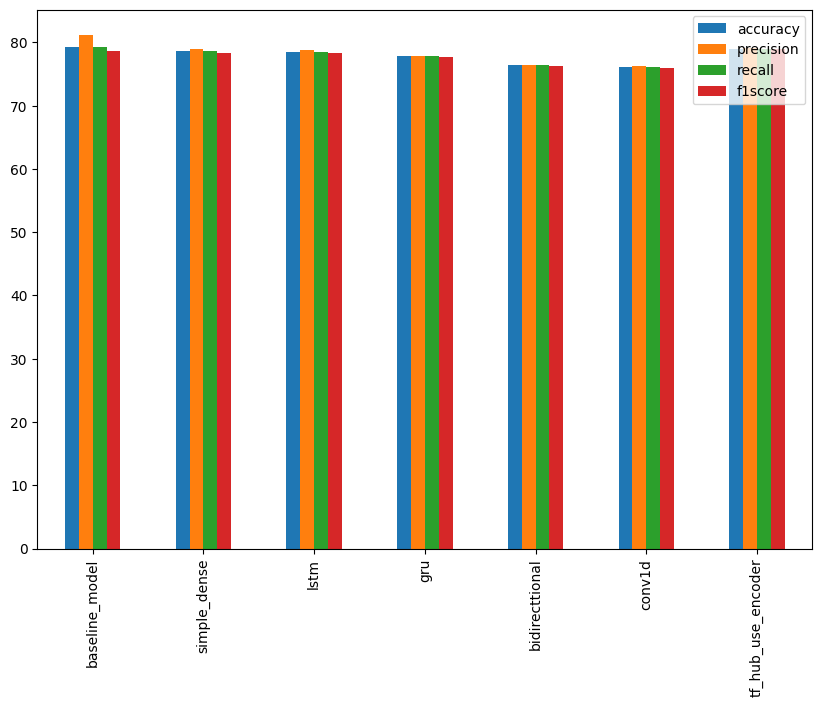

In [ ]:
all_models_results.plot(kind ="bar", figsize = (10,7))

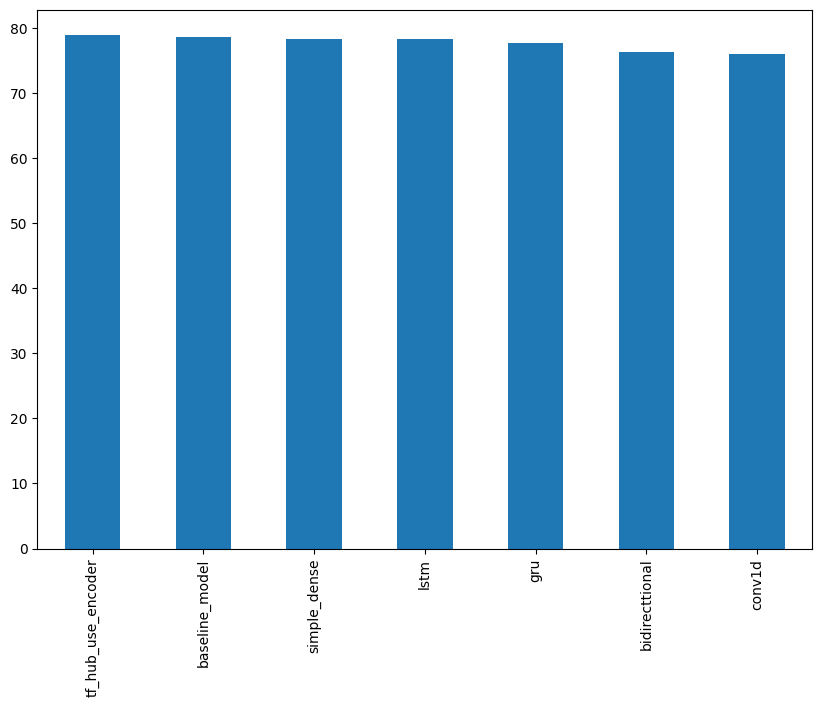

In [ ]:
all_models_results.sort_values('f1score',ascending=False)['f1score'].plot(kind='bar',figsize=(10,7));

In [ ]:
model_6.save('drive/MyDrive/model/NLP.keras')

In [ ]:
loaded_model = tf.keras.models.load_model('drive/MyDrive/model/NLP.keras',
                                          custom_objects = {'KerasLayer': hub.KerasLayer})

In [ ]:
model_6.save('drive/MyDrive/model/NLP')

In [ ]:
loaded_model_all= tf.keras.models.load_model('drive/MyDrive/model/NLP')

In [ ]:
loaded_model.evaluate(val_sentences,val_labels)

24/24 [==============================] - 0s 4ms/step


TypeError: argument of type 'NoneType' is not iterable

In [ ]:
loaded_model_all.evaluate(val_sentences,val_labels)

24/24 [==============================] - 0s 13ms/step - loss: 0.4966 - accuracy: 0.7900


[0.49656742811203003, 0.7900262475013733]

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/08_model_6_USE_feature_extractor.zip
!unzip 08_model_6_USE_feature_extractor.zip

--2025-06-26 08:59:29--  https://storage.googleapis.com/ztm_tf_course/08_model_6_USE_feature_extractor.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.98.207, 142.251.107.207, 74.125.196.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 960779165 (916M) [application/zip]
Saving to: ‘08_model_6_USE_feature_extractor.zip’

08_model_6_USE_feat 100%[===================>] 916.27M   178MB/s    in 5.5s    

2025-06-26 08:59:35 (166 MB/s) - ‘08_model_6_USE_feature_extractor.zip’ saved [960779165/960779165]

Archive:  08_model_6_USE_feature_extractor.zip
   creating: 08_model_6_USE_feature_extractor/
   creating: 08_model_6_USE_feature_extractor/assets/
   creating: 08_model_6_USE_feature_extractor/variables/
  inflating: 08_model_6_USE_feature_extractor/variables/variables.data-00000-of-00001  
  inflating: 08_model_6_USE_feature_extractor/variables/variables.i

In [ ]:
model_6_pretrained = tf.keras.models.load_model("08_model_6_USE_feature_extractor")

In [ ]:
model_6_pretrained.evaluate(val_sentences,val_labels)

24/24 [==============================] - 1s 14ms/step - loss: 0.4272 - accuracy: 0.8163


[0.42723119258880615, 0.8162729740142822]

In [ ]:
model_6_pretrained_pred_probs = model_6_pretrained.predict(val_sentences)

24/24 [==============================] - 1s 12ms/step


In [ ]:
model_6_pretrained_preds = tf.squeeze(tf.round(model_6_pretrained_pred_probs))

In [ ]:
val_df = pd.DataFrame({ 'text': val_sentences,
                       'target': val_labels,
                        'preds': model_6_pretrained_preds,
                        'pred_prob': tf.squeeze(model_6_pretrained_pred_probs)})
val_df.head()

,text,target,preds,pred_prob
0,DFR EP016 Monthly Meltdown - On Dnbheaven 2015...,0,0.0,0.159757
1,FedEx no longer to transport bioterror germs i...,0,1.0,0.747162
2,Gunmen kill four in El Salvador bus attack: Su...,1,1.0,0.988749
3,@camilacabello97 Internally and externally scr...,1,0.0,0.196229
4,Radiation emergency #preparedness starts with ...,1,1.0,0.707808


In [ ]:
most_wrong = val_df[val_df['target'] != val_df['preds']].sort_values('pred_prob', ascending=False)
most_wrong.head()

,text,target,preds,pred_prob
31,? High Skies - Burning Buildings ? http://t.co...,0,1.0,0.910196
759,FedEx will no longer transport bioterror patho...,0,1.0,0.876982
628,@noah_anyname That's where the concentration c...,0,1.0,0.852300
209,Ashes 2015: AustraliaÛªs collapse at Trent Br...,0,1.0,0.835454
251,@AshGhebranious civil rights continued in the ...,0,1.0,0.827213


In [ ]:
most_wrong.tail()

,text,target,preds,pred_prob
411,@SoonerMagic_ I mean I'm a fan but I don't nee...,1,0.0,0.043918
233,I get to smoke my shit in peace,1,0.0,0.042087
38,Why are you deluged with low self-image? Take ...,1,0.0,0.038998
244,Reddit Will Now QuarantineÛ_ http://t.co/pkUA...,1,0.0,0.038949
23,Ron &amp; Fez - Dave's High School Crush https...,1,0.0,0.037186
